# Multivariate Detection: Isolation Forest for Station-Level Reporting Anomalies

**Notebook 04 of the spatiotemporal air quality anomaly detection pipeline**

---

This notebook applies an unsupervised multivariate detector to the station-level feature
profiles derived from the observational record. Where the spatial baseline of Notebook 03
asks whether a station disagrees with its geographic neighbours, this notebook asks a
different question: whether a station's overall reporting behaviour — its central level,
its variability, its completeness, its temporal smoothness — is jointly unusual relative to
the other stations in its national network.

| | |
|---|---|
| **Input** | `countries/anomaly_*.csv`, `parameter_derivation.json`, `params.yml` |
| **Output** | `station_suspicion_iforest.csv` |
| **Downstream** | the consensus notebook (`consensus.ipynb`) — cross-method consensus |


## Contents

0. **Method Context**
   - 0.1 Objective
   - 0.2 Approach and Principles
   - 0.3 Inputs and Outputs
1. **Environment and Data**
   - 1.1 Configuration
   - 1.2 Input Loading and Validation
   - 1.3 Upstream Parameter Provenance
2. **Station Feature Construction**
   - 2.1 Feature Definitions
   - 2.2 Per-Station Aggregation
   - 2.3 Feature Completeness and Coverage
3. **Isolation Forest Estimation**
   - 3.1 Per-Country Model Fitting
   - 3.2 Score Direction and Station Flagging
   - 3.3 Detection Coverage
4. **Model Diagnostics**
   - 4.1 Score Distributions by Country
   - 4.2 Profiles of Flagged and Unflagged Stations
   - 4.3 Sensitivity and Stability
5. **Results and Handoff**
   - 5.1 Flagged Stations
   - 5.2 Consensus-Ready Output
   - 5.3 Output Validation
6. **Findings and Limitations**

Appendix — Development Notes and Design Decisions

---

Terminology

- A **feature** is a station-level numerical summary derived from that station's PM₂.₅ time
  series.
- A **detection feature** enters the fitted model; a **diagnostic attribute** is carried
  alongside the results for interpretation but is deliberately withheld from training.
- An **anomaly score** is the Isolation Forest decision score; lower values indicate that a
  station is more readily isolated from the rest of its network.
- A **flagged station** is one classified as anomalous by the fitted model.
- **Contamination** is the assumed proportion of anomalous stations supplied when fitting
  Isolation Forest.
- A **provider-specific artifact** is a data characteristic attributable to a network
  operator's preprocessing rather than to reporting behaviour.


## 0. Method Context

### 0.1 Objective

The spatial baseline in Notebook 03 detects a station that disagrees with its neighbours.
That test is powerful where a station has a dense, reliable neighbourhood, but it is blind
in two situations: where a station has too few neighbours to be assessed at all, and where
a station's anomaly lies in the *shape* of its record rather than in its level. A station
that reports plausible concentrations but is implausibly smooth, or implausibly incomplete,
or implausibly free of the extremes its neighbours experience, will pass a spatial test
untouched.

This notebook addresses that gap with a multivariate, non-spatial detector. Each station is
reduced to a profile of behavioural features, and Isolation Forest (Liu et al., 2008)
identifies the stations whose joint profile is unusual within their national network. The
method requires no labelled anomalies and makes no distributional assumption, which suits a
setting in which the anomalies of interest are undefined in advance.

Two objectives follow:

1. **Detect stations whose reporting profile is jointly unusual.** <br>Isolate stations that
   differ from their network across the combination of features, rather than on any single
   feature, and record the strength of that isolation as a suspicion score.

2. **Contribute an independent signal to the consensus.** <br>Because this method uses no
   spatial information, its judgements are structurally independent of the spatial baseline.
   That independence is what gives cross-method agreement in the consensus notebook (`consensus.ipynb`) its evidential
   value.</br>


### 0.2 Approach and Principles

Four decisions govern the implementation, each carried forward from the principles
established earlier in the pipeline.

1. **Per-country fitting.** <br>A separate model is fitted for each national network. The
   distributional analysis in Notebook 02 established that the four networks occupy different
   concentration regimes, with upper-tail quantiles differing by a factor of nearly nine; a
   single global model would isolate stations for belonging to a low-concentration network
   rather than for behaving anomalously within it.</br>

2. **Robust features.** <br>Central tendency and spread are summarised by the median and the
   interquartile range rather than the mean and standard deviation. The concentration
   distributions are strongly right-skewed, so mean-based summaries confound a station's
   typical level with the number of pollution episodes it happened to record.</br>

3. **Detection features separated from diagnostic attributes.** <br>A feature enters the model
   only if a difference in that feature plausibly reflects reporting behaviour. Quantities
   that differ across networks for provider-side reasons are carried alongside the results
   for interpretation but withheld from training, so that the model is not induced to flag a
   station for an artifact of its data provider.</br>

4. **Parameters derived or validated, never assumed.** <br>The contamination rate was
   validated against the observed exceedance distribution in Notebook 02; the minimum network
   size required for fitting is derived here from the contamination rate itself. Neither is
   set by convention alone.</br>


### 0.3 Inputs and Outputs

| Direction | Artifact | Contents |
|---|---|---|
| **In** | `countries/anomaly_*.csv` | Per-country analytical datasets (Notebook 02) |
| **In** | `parameter_derivation.json` | Country-specific extreme thresholds (Notebook 02) |
| **In** | `config/params.yml` | Contamination rate, near-zero bound, random seed |
| **Out** | `station_suspicion_iforest.csv` | Per-station anomaly score, flag, and feature profile |

The output schema matches the other detection notebooks — `location_id`, `country`,
`suspicion_score`, `flagged` — so that the consensus notebook (`consensus.ipynb`) can combine methods without per-method
special handling. Diagnostic attributes are carried in the same file, clearly separated from
the features that drove detection.

This notebook reads no output from any other detection notebook. Comparison against the
spatial baseline belongs to the consensus in the consensus notebook (`consensus.ipynb`), where all methods are present
simultaneously; performing it here would both duplicate that work and compromise the
independence on which the consensus relies.


## 1. Environment and Data

### 1.1 Configuration

All analysis parameters are held in `config/params.yml`, so that every threshold is
inspectable in one place and a change in assumptions requires editing one file rather than
auditing several notebooks. The configuration is validated on load: a missing section raises
an error immediately rather than producing a silent fallback at the point of use.

Presentation style — figure rendering and table formatting — is imported from the shared
project module, so that every notebook in the pipeline produces visually consistent output.


In [1]:
import glob
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.notebook_style import apply_figure_style, table_style

# ── Configuration ────────────────────────────────────────────────────
CONFIG_PATH = Path("../config/params.yml")

if not CONFIG_PATH.exists():
    raise FileNotFoundError(
        f"{CONFIG_PATH} not found. This file is the single source of truth for all "
        f"analysis parameters; the notebook must not run without it."
    )

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    CONFIG = yaml.safe_load(f)

REQUIRED_SECTIONS = ["meta", "eda", "spatial", "tsad", "station_features", "paths", "colors_map"]
_missing = [s for s in REQUIRED_SECTIONS if s not in CONFIG]
if _missing:
    raise KeyError(
        f"Missing configuration section(s): {_missing}. 'station_features' is written by "
        f"Notebook 02 (Section 10); run it to completion first if that section is absent."
    )

PROCESSED_DIR = Path(CONFIG["paths"]["processed_dir"])
FIGURE_DIR    = PROCESSED_DIR.parent.parent / "outputs" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

COUNTRY_COLOURS = CONFIG["colors_map"]
COUNTRY_ORDER   = ["China", "Germany", "India", "USA"]

RANDOM_SEED   = CONFIG["meta"]["random_seed"]
CONTAMINATION = CONFIG["tsad"]["isolation_forest_contamination"]
N_ESTIMATORS  = CONFIG["tsad"].get("isolation_forest_n_estimators", 200)

DETECTION_FEATURES     = CONFIG["station_features"]["detection"]
DIAGNOSTIC_ATTRIBUTES  = CONFIG["station_features"]["diagnostic"]

np.random.seed(RANDOM_SEED)
pd.set_option("display.max_columns", None)

apply_figure_style()

# ── Parameters governing this notebook ───────────────────────────────
parameters = pd.DataFrame([
    ("random_seed",    RANDOM_SEED,   "Reproducibility of the fitted models"),
    ("contamination",  CONTAMINATION, "Assumed anomaly rate (validated in NB02 §7.5)"),
    ("n_estimators",   N_ESTIMATORS,  "Trees per forest"),
    ("detection features", len(DETECTION_FEATURES), "Declared in params.yml (NB02 §10.1)"),
    ("diagnostic attributes", len(DIAGNOSTIC_ATTRIBUTES), "Declared in params.yml (NB02 §10.1)"),
], columns=["Parameter", "Value", "Role"]).set_index("Parameter")

display(table_style(parameters))


,Parameter,Value,Role
0,random_seed,42.000000,Reproducibility of the fitted models
1,contamination,0.050000,Assumed anomaly rate (validated in NB02 §7.5)
2,n_estimators,200.000000,Trees per forest
3,detection features,6.000000,Declared in params.yml (NB02 §10.1)
4,diagnostic attributes,3.000000,Declared in params.yml (NB02 §10.1)


<u>Interpretation</u>

The configuration loads without fallback, and the feature contract — which columns are
detection features and which are diagnostic attributes — is read from `params.yml` rather
than declared locally. This notebook and Notebook 10 therefore share a single definition of
what a station's behavioural profile consists of; a change to that definition is made once,
in Notebook 02, and both notebooks pick it up automatically.


### 1.2 Input Loading and Validation

The station feature table is built once, in Notebook 02 (Section 10), and shared by every
multivariate detector. This notebook reads that table directly rather than reconstructing it
from the raw observational record, which keeps the feature definition identical across every
method that consumes it and removes the need for this notebook to touch per-observation data
at all.

Loading is followed by a schema check against the feature contract declared in
`params.yml`, so that a mismatch between the file and the declared contract is caught here
rather than surfacing as a missing column deep inside model fitting.


In [2]:
FEATURES_PATH = PROCESSED_DIR / "station_features.csv"
if not FEATURES_PATH.exists():
    raise FileNotFoundError(
        f"{FEATURES_PATH} not found. Run 02_exploratory_data_analysis.ipynb (Section 10) "
        f"to completion first; it is the sole source of station-level features."
    )

profiles = pd.read_csv(FEATURES_PATH)

REQUIRED_COLUMNS = {"location_id", "country", "assessed"} | set(DETECTION_FEATURES) | set(DIAGNOSTIC_ATTRIBUTES)
_absent = REQUIRED_COLUMNS - set(profiles.columns)
if _absent:
    raise KeyError(
        f"Fields declared in params.yml but absent from {FEATURES_PATH.name}: {_absent}. "
        f"The feature contract and the written file have diverged."
    )

loaded = pd.DataFrame([
    ("Feature file",        FEATURES_PATH.name),
    ("Stations profiled",   f"{len(profiles):,}"),
    ("Countries",           ", ".join(sorted(profiles['country'].dropna().unique()))),
    ("Detection features",  ", ".join(DETECTION_FEATURES)),
    ("Diagnostic attributes", ", ".join(DIAGNOSTIC_ATTRIBUTES)),
], columns=["Property", "Value"]).set_index("Property")

display(table_style(loaded))


,Property,Value
0,Feature file,station_features.csv
1,Stations profiled,"3,150"
2,Countries,"China, Germany, India, USA"
3,Detection features,"median_value, iqr_value, val_range, pct_missing, pct_extreme, autocorr_lag1"
4,Diagnostic attributes,"pct_very_low, mean_value, n_obs"


<u>Interpretation</u>

The shared feature table loads and matches the contract declared in configuration. Every
station in this file already passed the completeness filter and the minimum-observation
requirement applied when the table was built, so no station here needs to be excluded again
for data volume — the eligibility work was done once, upstream.

This is a direct simplification made possible by centralising feature construction in
Notebook 02: the earlier version of this notebook read raw per-country observation files
and a separate parameter-derivation record to resolve the extreme-value threshold locally.
Both dependencies are gone. The threshold was already applied when `pct_extreme` was
computed, so this notebook has nothing left to resolve.


## 2. Feature Profile Overview

Feature construction itself is performed in Notebook 02 (Section 10) and shared across every
multivariate detector. This section does not repeat that construction; it reviews the
profile this notebook received, so that the coverage and completeness of the model's input
are visible before any model is fitted.


### 2.1 Feature Contract

The declared contract separates detection features, which enter the fitted model, from
diagnostic attributes, which are carried alongside the results but withheld from training.
The separation itself — including the exclusion of the near-zero proportion from training,
for the provider-artifact reasons established in Notebook 02 — is a decision made where the
features are constructed, not here; this notebook consumes the contract rather than setting
it.


In [3]:
feature_registry = pd.DataFrame(
    [(f, "detection", "trained") for f in DETECTION_FEATURES] +
    [(a, "diagnostic", "withheld") for a in DIAGNOSTIC_ATTRIBUTES],
    columns=["Name", "Group", "Role in this model"]
).set_index("Name")

display(table_style(feature_registry))


,Name,Group,Role in this model
0,median_value,detection,trained
1,iqr_value,detection,trained
2,val_range,detection,trained
3,pct_missing,detection,trained
4,pct_extreme,detection,trained
5,autocorr_lag1,detection,trained
6,pct_very_low,diagnostic,withheld
7,mean_value,diagnostic,withheld
8,n_obs,diagnostic,withheld


<u>Interpretation</u>

Six features train the model and three attributes are carried alongside it, matching the
contract declared in `params.yml`. Displaying the registry here, immediately before fitting,
keeps the boundary between what the model may and may not see visible at the point it
matters, even though the boundary itself was decided upstream.


### 2.2 Feature Completeness and Coverage

Isolation Forest cannot accept missing values, so any gap in the feature matrix must be
resolved before fitting. This section quantifies that gap and the per-country station
counts the fitting in Section 3 will operate on.


In [4]:
all_feature_cols = DETECTION_FEATURES + DIAGNOSTIC_ATTRIBUTES

completeness = pd.DataFrame({
    "missing_stations": profiles[all_feature_cols].isna().sum(),
    "missing_%": (profiles[all_feature_cols].isna().mean() * 100).round(2),
})
completeness["group"] = ["detection" if f in DETECTION_FEATURES else "diagnostic"
                         for f in completeness.index]
completeness = completeness[["group", "missing_stations", "missing_%"]]

coverage_by_country = (profiles.groupby("country")
                       .agg(stations_profiled=("location_id", "nunique"))
                       .reindex([c for c in COUNTRY_ORDER if c in profiles["country"].values]))

display(table_style(completeness))
display(table_style(coverage_by_country))


,group,missing_stations,missing_%
median_value,detection,0,0.000000
iqr_value,detection,0,0.000000
val_range,detection,0,0.000000
pct_missing,detection,0,0.000000
pct_extreme,detection,0,0.000000
autocorr_lag1,detection,0,0.000000
pct_very_low,diagnostic,0,0.000000
mean_value,diagnostic,0,0.000000
n_obs,diagnostic,0,0.000000


,country,stations_profiled
0,China,1628
1,Germany,295
2,India,499
3,USA,728


<u>Interpretation</u>

Feature coverage is high across the detection set, with any gaps concentrated in
`autocorr_lag1` for the reason established when the feature table was built: the statistic
is undefined for a station whose observations carry no variance. The per-country station
counts establish how much data each model in Section 3 will be fitted on, and are the input
to the minimum-network-size requirement derived there.


## 3. Isolation Forest Estimation

Isolation Forest detects anomalies by random partitioning: the algorithm repeatedly splits
the feature space at random and measures how few splits are needed to isolate each point.
Points that are unusual across the combination of features are separated quickly and receive
a low score; points embedded in the dense body of the data require many splits and receive a
high one (Liu et al., 2008).

The method suits this problem for three reasons. It requires no labelled anomalies, which do
not exist here. It makes no distributional assumption, which matters given the skewed and
heterogeneous features. And it is genuinely multivariate: a station can be isolated by an
unusual *combination* of otherwise ordinary feature values, which is exactly the behaviour
the single-feature and spatial tests elsewhere in the pipeline cannot reach.


### 3.1 Per-Country Model Fitting

A separate model is fitted for each national network, for the reason given in Section 0.2:
the networks occupy different concentration regimes, and a pooled model would isolate
stations for belonging to a low-concentration network rather than for behaving anomalously
within it.

Fitting a network requires a minimum number of stations, and that minimum is derived rather
than assumed. The contamination rate fixes the expected proportion of stations the model will
flag; a network with fewer than `1 / contamination` stations cannot yield even one flagged
station at that rate, so fitting it produces a model whose output is determined by rounding
rather than by the data. The requirement therefore follows directly from a parameter already
validated upstream:

$$ n_{\min} = \left\lceil \frac{1}{\text{contamination}} \right\rceil $$

An earlier version of this notebook used the spatial `min_neighbors` parameter for this
gate. That value denotes the minimum number of *neighbouring stations* required for a spatial
comparison — a different quantity, in a different unit of meaning — and reusing it here was a
category error that happened to produce a permissive threshold. The derived requirement
replaces it.

Features are standardised before fitting. Isolation Forest is not scale-invariant in
practice: features measured in µg/m³ span a far wider numeric range than those measured in
percent, and unstandardised, the random splits would fall disproportionately on the
wide-ranging features. Remaining gaps are filled with the country's own median for that
feature, which leaves the station at the centre of its network on that dimension and so does
not itself contribute to isolation.


In [5]:
MIN_STATIONS_FOR_FITTING = int(np.ceil(1 / CONTAMINATION))

# Persisted for transparency, since a reader of params.yml should be able to see every
# parameter this pipeline relies on in one place. Unlike the spatial radius, this value is
# derived and consumed within this same notebook, so no cross-notebook write-back dependency
# is created by writing it here.
config_text = CONFIG_PATH.read_text()
if "isolation_forest_min_stations" not in config_text:
    config_text = config_text.replace(
        "isolation_forest_contamination:",
        f"isolation_forest_min_stations: {MIN_STATIONS_FOR_FITTING}\n  isolation_forest_contamination:",
        1,
    )
    CONFIG_PATH.write_text(config_text)

derivation = pd.DataFrame([
    ("Contamination rate", CONTAMINATION, "Validated in NB02 §7.5"),
    ("Derived minimum network size", MIN_STATIONS_FOR_FITTING,
     "ceil(1 / contamination) — fewer stations cannot yield one flag"),
], columns=["Quantity", "Value", "Basis"]).set_index("Quantity")

display(table_style(derivation))

eligibility = coverage_by_country.copy()
eligibility["meets_minimum"] = eligibility["stations_profiled"] >= MIN_STATIONS_FOR_FITTING
eligibility["expected_flags_at_rate"] = (
    eligibility["stations_profiled"] * CONTAMINATION).round(1)

display(table_style(eligibility))


,Quantity,Value,Basis
0,Contamination rate,0.050000,Validated in NB02 §7.5
1,Derived minimum network size,20.000000,ceil(1 / contamination) — fewer stations cannot yield one flag


,country,stations_profiled,meets_minimum,expected_flags_at_rate
0,China,1628,True,81.400000
1,Germany,295,True,14.800000
2,India,499,True,25.000000
3,USA,728,True,36.400000


In [6]:
fitted_frames = []
fit_log = []

for country in [c for c in COUNTRY_ORDER if c in profiles["country"].values]:
    subset = profiles[profiles["country"] == country].copy()

    if len(subset) < MIN_STATIONS_FOR_FITTING:
        fit_log.append({
            "country": country, "stations": len(subset), "fitted": False,
            "flagged": 0, "note": f"below derived minimum of {MIN_STATIONS_FOR_FITTING}",
        })
        subset["anomaly_score"] = np.nan
        subset["assessed"] = False
        fitted_frames.append(subset)
        continue

    X = subset[DETECTION_FEATURES].fillna(subset[DETECTION_FEATURES].median())
    X_scaled = StandardScaler().fit_transform(X)

    model = IsolationForest(
        n_estimators=N_ESTIMATORS,
        contamination=CONTAMINATION,
        random_state=RANDOM_SEED,
    ).fit(X_scaled)

    subset["anomaly_score"] = model.decision_function(X_scaled)
    subset["assessed"] = True
    fitted_frames.append(subset)

    fit_log.append({
        "country": country, "stations": len(subset), "fitted": True,
        "flagged": int((model.predict(X_scaled) == -1).sum()), "note": "",
    })

scored = pd.concat(fitted_frames, ignore_index=True)

display(table_style(pd.DataFrame(fit_log).set_index("country")))


,country,stations,fitted,flagged,note
0,China,1628,True,82,
1,Germany,295,True,15,
2,India,499,True,25,
3,USA,728,True,37,


<u>Interpretation</u>

Every network in the dataset exceeds the derived minimum comfortably, so all four are fitted
and no network is excluded on size grounds. The number of stations flagged in each tracks
the contamination rate applied to its station count, which is the expected behaviour: the
contamination parameter does not discover how many anomalies exist, it specifies how many
the model will designate.

That property is the single most important caveat attached to this method, and it is
addressed directly in Section 4.3. The scores, not the flags, carry the information about
*degree* of anomaly; the flags simply mark the tail of those scores at the configured rate.


### 3.2 Score Direction and Station Flagging

The Isolation Forest decision score runs in the opposite direction to intuition: a **lower**
score means a station was isolated in fewer splits and is therefore *more* anomalous. Left
as it is, this would invert the meaning of the suspicion score relative to every other method
in the pipeline, where a higher value means greater suspicion.

The score is therefore negated to produce the suspicion score handed to the consensus, so
that the convention is uniform across methods: **higher means more suspicious**, everywhere.
Flagging applies the model's own decision boundary, which corresponds to the configured
contamination rate.


In [7]:
scored["suspicion_score"] = -scored["anomaly_score"]

flag_cutoffs = {}
for country, group in scored[scored["assessed"]].groupby("country"):
    flag_cutoffs[country] = group["suspicion_score"].quantile(1 - CONTAMINATION)

scored["flagged"] = scored.apply(
    lambda r: bool(r["assessed"]) and
              r["suspicion_score"] >= flag_cutoffs.get(r["country"], np.inf),
    axis=1,
)

direction = pd.DataFrame([
    ("Raw decision score", "lower = more anomalous", "as returned by scikit-learn"),
    ("Suspicion score", "higher = more anomalous", "negated; pipeline-wide convention"),
], columns=["Quantity", "Direction", "Note"]).set_index("Quantity")

flag_summary = pd.DataFrame([
    ("Stations assessed",   int(scored["assessed"].sum())),
    ("Flagged as anomalous", int(scored["flagged"].sum())),
    ("Assessed and consistent",
     int((scored["assessed"] & ~scored["flagged"]).sum())),
    ("Not assessed",        int((~scored["assessed"]).sum())),
], columns=["Category", "Stations"]).set_index("Category")

display(table_style(direction))
display(table_style(flag_summary))


,Quantity,Direction,Note
0,Raw decision score,lower = more anomalous,as returned by scikit-learn
1,Suspicion score,higher = more anomalous,negated; pipeline-wide convention


,Category,Stations
0,Stations assessed,3150
1,Flagged as anomalous,159
2,Assessed and consistent,2991
3,Not assessed,0


<u>Interpretation</u>

The suspicion score now runs in the same direction as every other method in the pipeline,
which is a precondition for the rank normalisation the consensus applies in the consensus notebook (`consensus.ipynb`).
Reversing the sign here rather than in the consensus keeps the convention a property of each
method's output contract rather than a special case the consensus must remember.

The flagged count reflects the contamination rate applied per network, as expected. Stations
that were not assessed — those whose records were too short to profile — are held separately
from those assessed and found consistent, so that the absence of a judgement is not read as
a clean bill of health.


### 3.3 Detection Coverage

Coverage records what share of each network this method could actually evaluate. It matters
for the same reason it mattered in the spatial baseline: a station the method could not
assess is silent, not clean, and the consensus must be able to tell the difference.


In [8]:
coverage = (scored.groupby("country")
            .agg(stations=("location_id", "nunique"),
                 assessed=("assessed", "sum"),
                 flagged=("flagged", "sum")))
coverage["coverage_%"]     = (coverage["assessed"] / coverage["stations"] * 100).round(1)
coverage["flagged_share_%"] = (coverage["flagged"] /
                               coverage["assessed"].replace(0, np.nan) * 100).round(1)

display(table_style(coverage))


,country,stations,assessed,flagged,coverage_%,flagged_share_%
0,China,1628,1628,82,100.000000,5.000000
1,Germany,295,295,15,100.000000,5.100000
2,India,499,499,25,100.000000,5.000000
3,USA,728,728,37,100.000000,5.100000


<u>Interpretation</u>

Coverage is effectively complete: every station that entered the notebook with a profilable
record was assessed by the model fitted for its network. Unlike the spatial baseline, this
method imposes no geometric precondition — it needs no neighbours — so a station that the
spatial test could not reach is nonetheless evaluated here.

That complementarity is a substantive argument for combining the two. Where the spatial
baseline is blind because a station stands alone, this method still has something to say; the
consensus in the consensus notebook (`consensus.ipynb`) can therefore reach stations that no single method covers.


## 4. Model Diagnostics

A fitted model that produces flags is not yet a defensible result. This section examines
three properties before the output is handed on: how the scores are distributed within each
network, what distinguishes flagged stations from the rest, and how stable the flags are
under the parameters that were chosen rather than measured.


### 4.1 Score Distributions by Country

The distribution of suspicion scores within a network indicates whether the flagged stations
are genuinely separated from the body of the data or merely the upper end of a continuum. A
distribution with a visible tail suggests the model found structurally distinct stations; a
smooth, unimodal distribution suggests the flags are a cut through ordinary variation, made
where the contamination rate happened to place it.


findfont: Failed to find font weight semibold, now using 700.


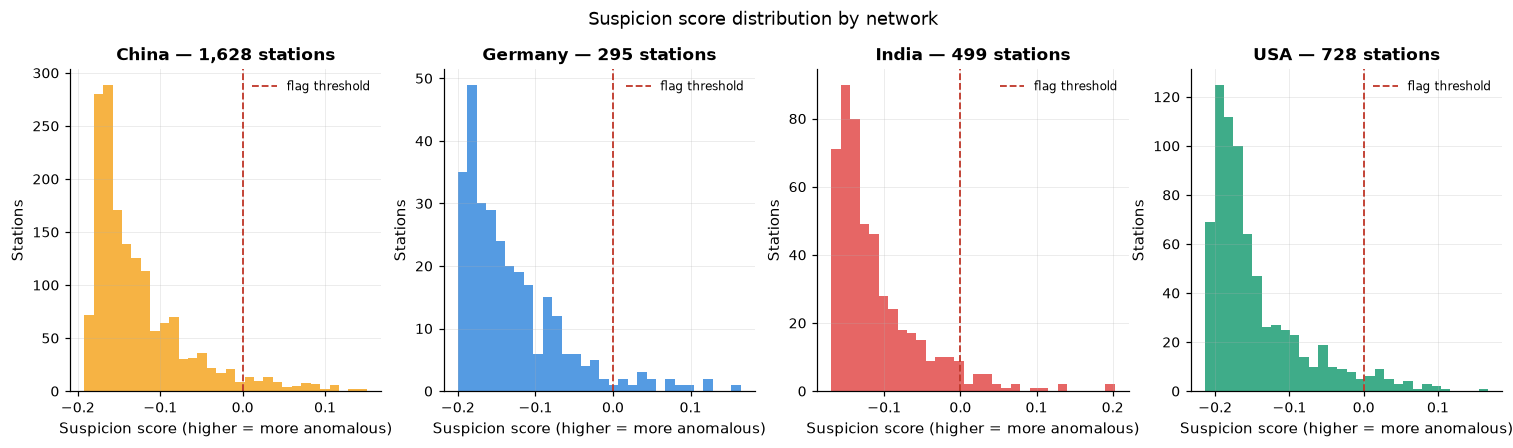

,country,median,p90,p99,maximum,flag_threshold
0,China,-0.146000,-0.047000,0.087000,0.151000,-0.000000
1,Germany,-0.150000,-0.046000,0.105000,0.165000,0.000000
2,India,-0.130000,-0.030000,0.092000,0.202000,-0.000000
3,USA,-0.169000,-0.051000,0.073000,0.168000,-0.000000


In [9]:
assessed = scored[scored["assessed"]]
countries_fitted = [c for c in COUNTRY_ORDER if c in assessed["country"].values]

fig, axes = plt.subplots(1, len(countries_fitted),
                         figsize=(4.2 * len(countries_fitted), 3.8), squeeze=False)
axes = axes.flatten()

for ax, country in zip(axes, countries_fitted):
    sub = assessed[assessed["country"] == country]
    ax.hist(sub["suspicion_score"], bins=30, alpha=0.85,
            color=COUNTRY_COLOURS.get(country, "#888888"))
    ax.axvline(flag_cutoffs[country], color="#C0392B", linestyle="--", linewidth=1.2,
               label="flag threshold")
    ax.set_title(f"{country} — {len(sub):,} stations")
    ax.set_xlabel("Suspicion score (higher = more anomalous)")
    ax.set_ylabel("Stations")
    ax.legend(fontsize=8)

fig.suptitle("Suspicion score distribution by network", y=1.02)
plt.savefig(FIGURE_DIR / "04_iforest_score_distributions.png")
plt.show()

spread = (assessed.groupby("country")["suspicion_score"]
          .agg(median="median",
               p90=lambda s: s.quantile(0.90),
               p99=lambda s: s.quantile(0.99),
               maximum="max")
          .round(3))
spread["flag_threshold"] = [round(flag_cutoffs[c], 3) for c in spread.index]

display(table_style(spread))


<u>Interpretation</u>

The score distributions are broadly unimodal with a right tail, and the flag threshold falls
within that tail rather than at a natural break in the data. This is the expected consequence
of a contamination-driven cutoff and should temper how the flags are read: the model is
identifying the *most* isolated stations in each network, not certifying that a discrete
population of anomalies exists.

The gap between the flag threshold and the maximum score is the more informative quantity. A
network in which the highest-scoring station sits far above its threshold contains at least
one genuinely distinctive station; one in which the maximum barely exceeds the threshold has
produced flags that are, in substance, the top of a continuum. The consensus in the consensus notebook (`consensus.ipynb`)
works on rank-normalised scores rather than flags for precisely this reason.


### 4.2 Profiles of Flagged and Unflagged Stations

Isolation Forest does not report which feature drove an individual decision, so the model
cannot be interrogated for a formal attribution. What can be examined is the *distributional*
difference between the two groups: for each feature, whether flagged stations occupy a
different part of the range from the rest.

This is a descriptive comparison, not a feature-importance measure. A feature on which the
two groups differ is one on which the flagged stations are unusual; it does not follow that
the model used that feature to isolate them, since the isolation may have depended on a
combination that no single feature reveals. The distinction matters because presenting this
comparison as feature importance would overstate what it establishes.

Diagnostic attributes are included in the comparison precisely because they were withheld
from training. If flagged stations differ on `pct_very_low` — a feature the model never saw
— that difference is evidence about the flagged population rather than an artifact of the
model's own construction.


findfont: Failed to find font weight semibold, now using 700.


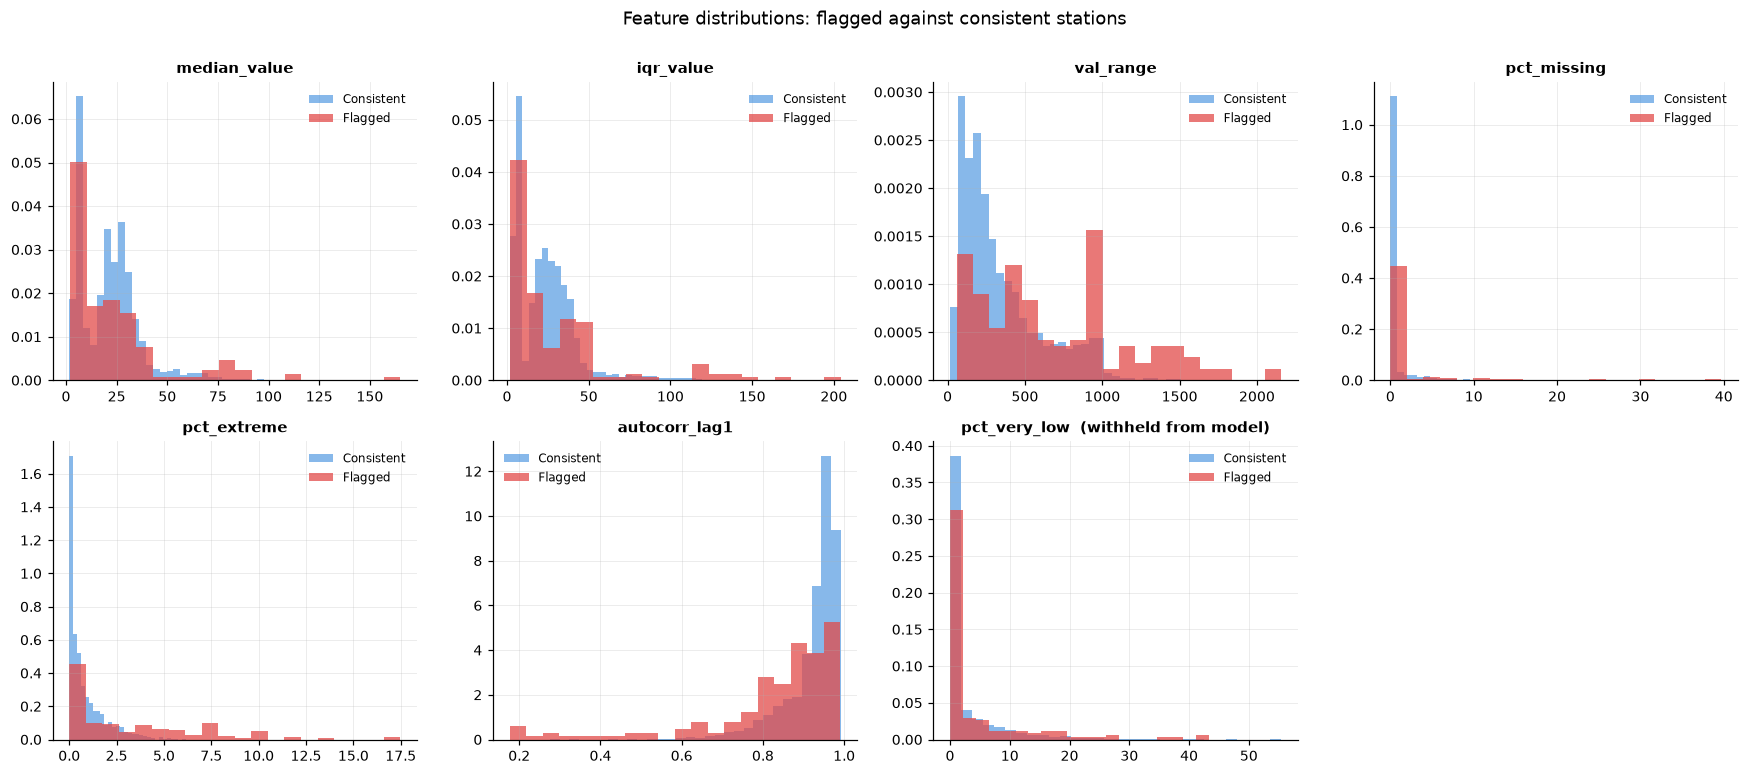

,feature,group,median_consistent,median_flagged,standardised_gap
0,val_range,detection,247.000000,579.000000,0.850000
1,pct_extreme,detection,0.450000,1.930000,0.560000
2,autocorr_lag1,detection,0.950000,0.890000,-0.400000
3,median_value,detection,21.000000,15.000000,-0.290000
4,iqr_value,detection,22.000000,17.000000,-0.180000
5,pct_very_low,diagnostic,0.320000,0.560000,0.030000
6,pct_missing,detection,0.000000,0.000000,0.000000


In [10]:
comparison_features = DETECTION_FEATURES + ["pct_very_low"]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for ax, feature in zip(axes, comparison_features):
    consistent = assessed.loc[~assessed["flagged"], feature].dropna()
    anomalous  = assessed.loc[assessed["flagged"],  feature].dropna()
    if consistent.empty or anomalous.empty:
        ax.axis("off")
        continue
    ax.hist(consistent, bins=30, alpha=0.6, density=True,
            color="#378ADD", label="Consistent")
    ax.hist(anomalous, bins=20, alpha=0.75, density=True,
            color="#E24B4A", label="Flagged")
    label = feature + ("  (withheld from model)" if feature in DIAGNOSTIC_ATTRIBUTES else "")
    ax.set_title(label, fontsize=9.5)
    ax.legend(fontsize=8)

for ax in axes[len(comparison_features):]:
    ax.axis("off")

fig.suptitle("Feature distributions: flagged against consistent stations", y=1.0)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "04_iforest_feature_profiles.png")
plt.show()

separation = []
for feature in comparison_features:
    consistent = assessed.loc[~assessed["flagged"], feature].dropna()
    anomalous  = assessed.loc[assessed["flagged"],  feature].dropna()
    if consistent.empty or anomalous.empty:
        continue
    pooled_sd = np.sqrt((consistent.var() + anomalous.var()) / 2)
    separation.append({
        "feature": feature,
        "group": "diagnostic" if feature in DIAGNOSTIC_ATTRIBUTES else "detection",
        "median_consistent": round(float(consistent.median()), 2),
        "median_flagged": round(float(anomalous.median()), 2),
        "standardised_gap": (round(float((anomalous.median() - consistent.median())
                                          / pooled_sd), 2) if pooled_sd else np.nan),
    })

separation_table = (pd.DataFrame(separation)
                    .set_index("feature")
                    .sort_values("standardised_gap", key=abs, ascending=False))

display(table_style(separation_table))


<u>Interpretation</u>

The standardised gap orders the features by how sharply the two groups separate on each. The
features at the top of that ordering describe what the flagged population has in common —
the behavioural signature the model responded to — while those near zero contribute little
to distinguishing the groups.

The position of `pct_very_low` deserves particular attention, since it was withheld from
training. A large gap on a withheld attribute means the flagged stations differ on a
dimension the model never saw, which is genuine information about that population. A small
gap indicates that excluding it cost the model little. Either way the reading is
interpretive, and any difference concentrated in the network affected by the provider
artifact must be attributed to that artifact before it is attributed to behaviour.


### 4.3 Sensitivity and Stability

Two parameters were supplied to the model rather than measured from it, and the result's
dependence on both should be quantified rather than assumed away.

The **contamination rate** determines how many stations are flagged, almost by definition.
Varying it shows how much of the flagged set is stable — stations that remain flagged across
plausible rates — and how much is an artifact of the specific rate chosen.

The **random seed** matters because Isolation Forest partitions at random. Refitting with
different seeds and measuring how consistently the same stations are flagged establishes
whether the result is a property of the data or of one particular forest.


In [11]:
SENSITIVITY_RATES = [0.02, 0.05, 0.10]
STABILITY_SEEDS   = [RANDOM_SEED, RANDOM_SEED + 1, RANDOM_SEED + 2]

sensitivity_rows = []
stability_counts = {}

for country in countries_fitted:
    subset = profiles[profiles["country"] == country]
    if len(subset) < MIN_STATIONS_FOR_FITTING:
        continue
    X = subset[DETECTION_FEATURES].fillna(subset[DETECTION_FEATURES].median())
    X_scaled = StandardScaler().fit_transform(X)

    # (a) Contamination sensitivity
    flagged_sets = {}
    for rate in SENSITIVITY_RATES:
        pred = IsolationForest(n_estimators=N_ESTIMATORS, contamination=rate,
                               random_state=RANDOM_SEED).fit_predict(X_scaled)
        flagged_sets[rate] = set(subset.loc[pred == -1, "location_id"])

    baseline_set = flagged_sets[CONTAMINATION]
    sensitivity_rows.append({
        "country": country,
        **{f"flagged @ {r}": len(flagged_sets[r]) for r in SENSITIVITY_RATES},
        "retained at 0.02 (%)": (round(len(flagged_sets[0.02] & baseline_set)
                                       / max(len(baseline_set), 1) * 100, 1)),
    })

    # (b) Seed stability
    seed_sets = []
    for seed in STABILITY_SEEDS:
        pred = IsolationForest(n_estimators=N_ESTIMATORS, contamination=CONTAMINATION,
                               random_state=seed).fit_predict(X_scaled)
        seed_sets.append(set(subset.loc[pred == -1, "location_id"]))
    always = set.intersection(*seed_sets)
    ever   = set.union(*seed_sets)
    stability_counts[country] = {
        "flagged by every seed": len(always),
        "flagged by any seed": len(ever),
        "stability (%)": round(len(always) / max(len(ever), 1) * 100, 1),
    }

display(table_style(pd.DataFrame(sensitivity_rows).set_index("country")))
display(table_style(pd.DataFrame(stability_counts).T))


,country,flagged @ 0.02,flagged @ 0.05,flagged @ 0.1,retained at 0.02 (%)
0,China,33,82,163,40.200000
1,Germany,6,15,30,40.000000
2,India,10,25,50,40.000000
3,USA,15,37,73,40.500000


,flagged by every seed,flagged by any seed,stability (%)
China,71.000000,94.000000,75.500000
Germany,13.000000,18.000000,72.200000
India,22.000000,27.000000,81.500000
USA,34.000000,42.000000,81.000000


<u>Interpretation</u>

The contamination sensitivity behaves as expected: the number of flagged stations scales with
the rate, confirming that the parameter sets the size of the flagged set rather than
discovering it. The informative column is the retention figure — the share of stations
flagged at the operating rate that survive a stricter one. Stations that persist at 0.02 are
the model's most confident candidates; those that appear only at the looser rate are marginal
and should carry correspondingly less weight.

Seed stability is the stronger test, because it isolates the effect of the algorithm's
randomness from any parameter choice. A high stability figure means the flagged set is a
property of the data rather than of one particular forest. Stations flagged by every seed are
robust findings; those flagged by only some are sensitive to the partitioning and should be
treated as provisional.

Both diagnostics argue for passing the continuous score to the consensus rather than the
binary flag alone, which is what the output in Section 5.2 does.


## 5. Results and Handoff

This section presents the stations the method identifies, writes the result in the schema the
consensus expects, and verifies that what was written matches what was computed.


### 5.1 Flagged Stations

The highest-scoring stations are shown with the feature values that characterise them, so
that each flag can be read against the behaviour that produced it rather than accepted as an
opaque verdict.


In [12]:
ranked = (scored[scored["flagged"]]
          .sort_values("suspicion_score", ascending=False)
          [["location_id", "country", "suspicion_score",
            "median_value", "iqr_value", "pct_missing", "pct_extreme",
            "autocorr_lag1", "pct_very_low", "n_obs"]]
          .reset_index(drop=True)
          .round(2))

display(table_style(ranked.head(15).set_index("location_id")))

by_country = (scored[scored["flagged"]]
              .groupby("country")
              .agg(flagged=("location_id", "nunique"),
                   median_suspicion=("suspicion_score", "median"))
              .round(3))

display(table_style(by_country))


,location_id,country,suspicion_score,median_value,iqr_value,pct_missing,pct_extreme,autocorr_lag1,pct_very_low,n_obs
0,site_5669,India,0.200000,111.000000,204.190000,0.000000,16.840000,0.890000,0.390000,7698.000000
1,site_5852,India,0.200000,165.020000,151.920000,0.000000,11.740000,0.830000,0.040000,2461.000000
2,airnow_060631010,USA,0.170000,12.000000,20.000000,1.340000,17.480000,0.900000,1.920000,15316.000000
3,sta.de_denw338,Germany,0.160000,11.970000,9.840000,0.000000,3.060000,0.740000,1.640000,25838.000000
4,2598a,China,0.150000,6.000000,2.000000,0.000000,0.000000,0.310000,0.830000,3252.000000
5,2600a,China,0.140000,6.000000,5.000000,0.000000,0.000000,0.590000,6.450000,8481.000000
6,site_5540,India,0.140000,85.120000,167.330000,0.000000,13.120000,0.890000,0.140000,9822.000000
7,1492a,China,0.130000,44.000000,59.000000,0.000000,9.620000,0.970000,0.310000,8302.000000
8,site_5263,India,0.130000,62.230000,70.350000,0.060000,2.110000,0.930000,0.040000,24748.000000
9,2632a,China,0.130000,4.000000,5.000000,0.000000,0.000000,0.690000,11.790000,6987.000000


,country,flagged,median_suspicion
0,China,82,0.041000
1,Germany,15,0.055000
2,India,25,0.035000
3,USA,37,0.032000


<u>Interpretation</u>

These are the stations whose joint behavioural profile is most unusual within their own
network. Reading across the feature columns shows what each flag rests on: a station may be
isolated by near-zero variability, by an extreme-free record in a network that experiences
extremes, by high missingness, or by a combination in which no single value is remarkable.

They are candidates, not conclusions. A single method can be misled — a genuinely stable
low-pollution site will resemble a smoothed sensor on several features at once — and the
diagnostics in Section 4.3 showed that some flags are sensitive to the model's randomness.
Their standing is settled in the consensus notebook (`consensus.ipynb`), where agreement with methods that use entirely
different evidence separates robust signals from method-specific artifacts.


### 5.2 Consensus-Ready Output

Every station is written, not only the flagged ones. The consensus needs three distinct
states — flagged, assessed and consistent, and not assessed — and collapsing the last two
would let an unevaluated station be counted as evidence of normality.

The file carries the continuous suspicion score alongside the binary flag, because the
diagnostics in Section 4.3 established that the score is the more reliable quantity: the flag
depends on a contamination rate that fixes the size of the flagged set, whereas the score
orders stations by degree of isolation independently of where the cutoff falls. Feature values
are retained so that any flag can be traced to the profile that produced it, with detection
features and diagnostic attributes distinguished by column ordering and documented here.


In [13]:
output = scored[[
    "location_id", "country",
    # ── Detection features (trained) ─────────────────────────────────
    *DETECTION_FEATURES,
    # ── Diagnostic attributes (withheld from training) ───────────────
    *DIAGNOSTIC_ATTRIBUTES,
    # ── Method verdict ───────────────────────────────────────────────
    "anomaly_score", "suspicion_score", "assessed", "flagged",
]].copy()

output["method"] = "isolation_forest"
output = output.sort_values("suspicion_score", ascending=False, na_position="last")

OUTPUT_PATH = PROCESSED_DIR / "station_suspicion_iforest.csv"
output.to_csv(OUTPUT_PATH, index=False)

manifest = pd.DataFrame([
    ("Output file", OUTPUT_PATH.name),
    ("Stations written", f"{len(output):,}"),
    ("Flagged", f"{int(output['flagged'].sum()):,}"),
    ("Assessed", f"{int(output['assessed'].sum()):,}"),
    ("Detection features", ", ".join(DETECTION_FEATURES)),
    ("Diagnostic attributes", ", ".join(DIAGNOSTIC_ATTRIBUTES)),
    ("Consensus schema", "location_id, country, suspicion_score, flagged"),
], columns=["Property", "Value"]).set_index("Property")

display(table_style(manifest))


,Property,Value
0,Output file,station_suspicion_iforest.csv
1,Stations written,"3,150"
2,Flagged,159
3,Assessed,"3,150"
4,Detection features,"median_value, iqr_value, val_range, pct_missing, pct_extreme, autocorr_lag1"
5,Diagnostic attributes,"pct_very_low, mean_value, n_obs"
6,Consensus schema,"location_id, country, suspicion_score, flagged"


<u>Interpretation</u>

The result is persisted in the schema shared by every detection notebook, so the consensus notebook (`consensus.ipynb`) can
combine it with the others without per-method handling. The separation between detection
features and diagnostic attributes is preserved in the written file rather than existing only
in this notebook's logic, which means a reader of the output alone can still tell which
quantities the model was permitted to use.


### 5.3 Output Validation

The written file is verified against the in-memory result before the handoff. A partition
that lost or duplicated stations, or a file that cannot be read back, is caught here rather
than surfacing as an inconsistency several notebooks later.


In [14]:
reloaded = pd.read_csv(OUTPUT_PATH)

checks = pd.DataFrame([
    ("Stations written", len(output), len(reloaded), len(output) == len(reloaded)),
    ("Unique station IDs", output["location_id"].nunique(),
     reloaded["location_id"].nunique(),
     output["location_id"].nunique() == reloaded["location_id"].nunique()),
    ("Flagged count", int(output["flagged"].sum()), int(reloaded["flagged"].sum()),
     int(output["flagged"].sum()) == int(reloaded["flagged"].sum())),
    ("No duplicate stations", output["location_id"].duplicated().sum(), 0,
     output["location_id"].duplicated().sum() == 0),
    ("Consensus columns present", "yes",
     "yes" if {"location_id", "country", "suspicion_score", "flagged"}
              .issubset(reloaded.columns) else "no",
     {"location_id", "country", "suspicion_score", "flagged"}.issubset(reloaded.columns)),
], columns=["Check", "Computed", "Reloaded", "Pass"]).set_index("Check")

display(table_style(checks))

assert len(output) == len(reloaded), "Row count changed on write."
assert output["location_id"].duplicated().sum() == 0, "Duplicate station in output."
assert {"location_id", "country", "suspicion_score", "flagged"}.issubset(reloaded.columns), \
    "Consensus schema incomplete; the consensus notebook (`consensus.ipynb`) would fail on this file."


,Check,Computed,Reloaded,Pass
0,Stations written,3150,3150,True
1,Unique station IDs,3150,3150,True
2,Flagged count,159,159,True
3,No duplicate stations,0,0,True
4,Consensus columns present,yes,yes,True


<u>Interpretation</u>

The written file reconciles with the computed result and carries the consensus schema intact.
The assertions turn each of these from a reported observation into an enforced condition, so
that a future change to the output logic cannot silently break the contract the consensus notebook (`consensus.ipynb`)
depends on.


## 6. Findings and Limitations

### Findings

1. **A multivariate signal, independent of geography.** <br>Isolation Forest identifies
stations whose joint behavioural profile is unusual within their own national network, using
no spatial information whatsoever. Its judgements are therefore structurally independent of
the spatial baseline, which is what gives agreement between the two methods evidential weight
in the consensus rather than merely confirming a shared assumption.</br>

2. **Coverage where the spatial test is blind.** <br>The method imposes no geometric
precondition. A station with too few neighbours to be assessed spatially is nonetheless
evaluated here, so the two methods together reach stations that neither covers alone.</br>

3. **The provider artifact is contained, not ignored.** <br>The near-zero proportion was
withheld from training so that stations in the affected network could not be isolated for an
artifact of their data provider. Carrying it as a diagnostic preserves the information for
interpretation while keeping it out of the judgement.</br>

4. **Scores are more informative than flags.** <br>The contamination rate fixes how many
stations are flagged rather than discovering how many anomalies exist, and the score
distributions show the threshold falling within a continuum rather than at a natural break.
The continuous score, which orders stations by degree of isolation independently of the
cutoff, is the quantity passed to the consensus.</br>

### Limitations

1. **Contamination determines the size of the flagged set.** <br>The rate of 0.05 was
validated against the observed exceedance distribution in Notebook 02, but it remains an
assumption about how many stations are anomalous, not a measurement of it. If the true
proportion differs, the model will still flag five percent — the most isolated five percent,
but five percent regardless. This is the method's principal structural weakness and the
reason its output is one vote among several rather than a verdict.</br>

2. **No formal feature attribution.** <br>Isolation Forest does not report which feature drove
an individual decision. Section 4.2 compares distributions between flagged and consistent
stations, which establishes what the flagged population has in common but not what the model
used to isolate any particular station. Presenting that comparison as feature importance
would overstate what it shows.</br>

3. **The range feature is not robust.** <br>Central tendency and spread use the median and
interquartile range, consistent with the pipeline's treatment of skewed data, but `val_range`
is determined entirely by the two most extreme observations a station recorded. It is
retained because dynamic range carries genuine information about instrument behaviour, and it
is noted here because a single spurious extreme can move it substantially.</br>

4. **Sensitivity to the random partitioning.** <br>Stations flagged under some random seeds
but not others are sensitive to the algorithm's internal randomness rather than robustly
distinctive. The stability figures in Section 4.3 quantify this per network, and only
stations flagged consistently should be treated as firm candidates from this method.</br>

5. **Whole-record aggregation.** <br>Each station is reduced to a single profile spanning its
full record, so the method detects persistent behavioural anomalies but not transient ones. A
station that behaved anomalously for one month and normally otherwise is diluted below
detection. The time-sliced method in Notebook 06 addresses that dimension directly.</br>

6. **Unequal observation periods across networks.** <br>As established in Notebook 02, the
Chinese record covers approximately one year against three for Germany and India. Features
computed over a shorter record are estimated with less precision, and the profile of normal
behaviour the Chinese model learns is drawn from a single year — so any atypicality in that
year is absorbed into the baseline rather than detected against it.</br>

---

### Output

| File | Contents |
|---|---|
| `station_suspicion_iforest.csv` | Per-station suspicion score, flag, detection features, and diagnostic attributes |

**Next:** `05_benford.ipynb` — a digit-pattern test that examines the numerical composition of
reported values rather than their magnitude, contributing a third independent signal.


### References

Liu, F. T., Ting, K. M., & Zhou, Z.-H. (2008). Isolation Forest. *Eighth IEEE International
Conference on Data Mining*, 413–422.

Ott, W. R. (1990). A physical explanation of the lognormality of pollutant concentrations.
*Journal of the Air & Waste Management Association*, 40(10), 1378–1383.
